In [1]:
!pip install keras-tuner

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.4/129.4 kB 6.1 MB/s eta 0:00:00


Trial 30 Complete [00h 01m 12s]
val_accuracy: 0.8170608282089233

Best val_accuracy So Far: 0.9003941416740417
Total elapsed time: 00h 15m 09s

Hyperparameter search complete.
Optimal units in hidden layer : 512
Optimal learning rate         : 0.001

Epoch 1/10
2220/2220 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.7881 - loss: 0.7045 - val_accuracy: 0.8591 - val_loss: 0.4528
Epoch 2/10
2220/2220 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8822 - loss: 0.3723 - val_accuracy: 0.8786 - val_loss: 0.3812
Epoch 3/10
2220/2220 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.9037 - loss: 0.2920 - val_accuracy: 0.8872 - val_loss: 0.3626
Epoch 4/10
2220/2220 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.9180 - loss: 0.2430 - val_accuracy: 0.8941 - val_loss: 0.3417
Epoch 5/10
2220/2220 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.9274 - loss: 0.2084 - val_accuracy: 0.8951 - val_loss: 0.3443
Epoch 6/10
2220/2220 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.9365 - loss: 0.1802 - val_accur

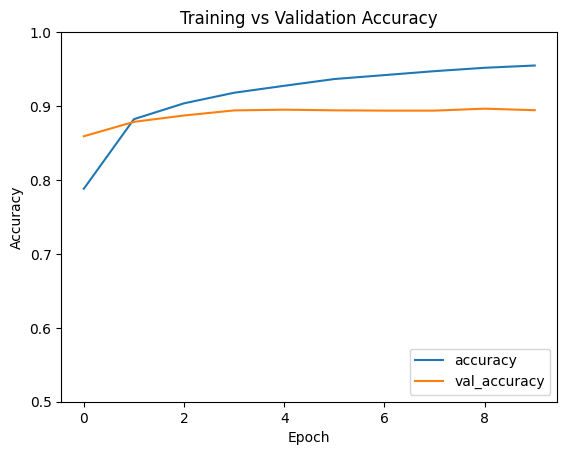

463/463 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


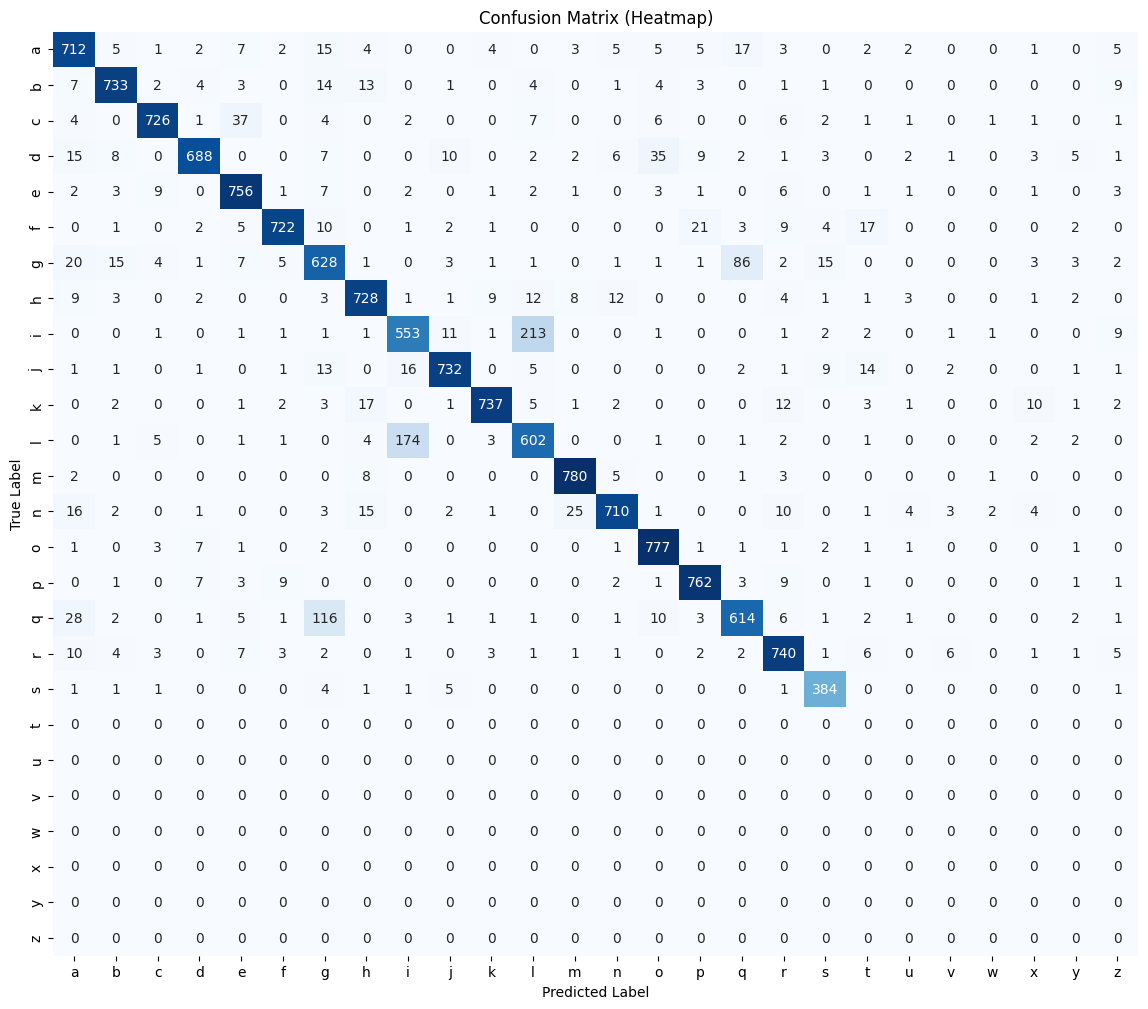

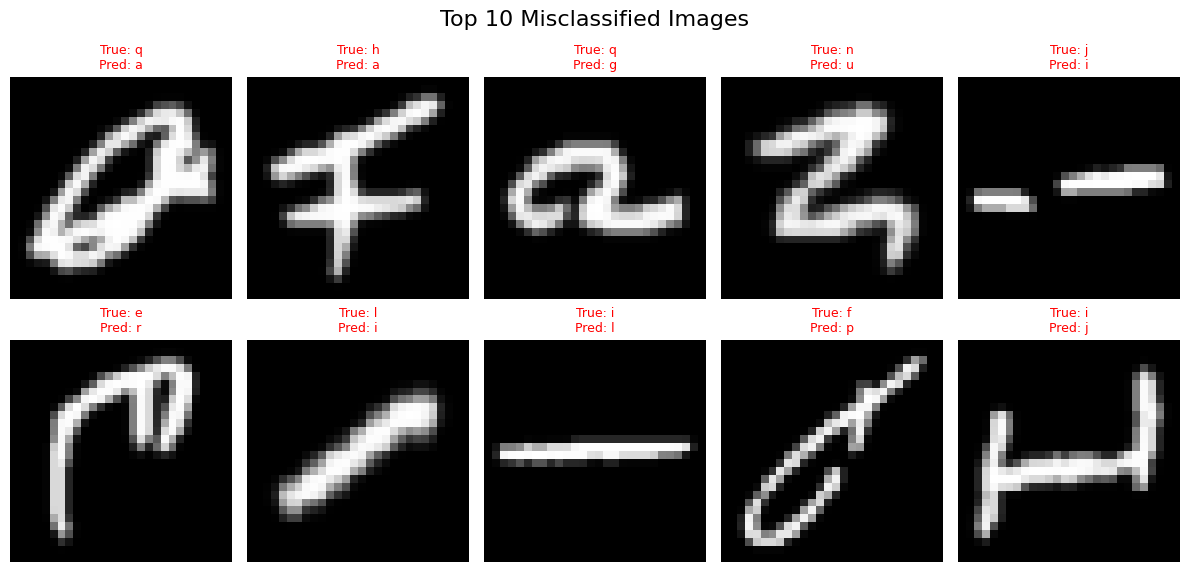

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 403ms/step


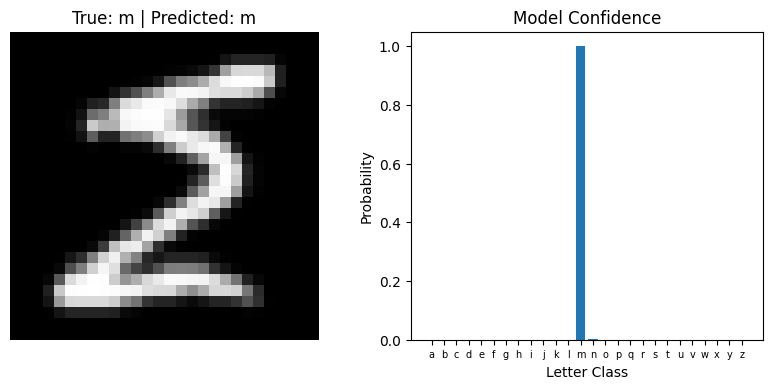

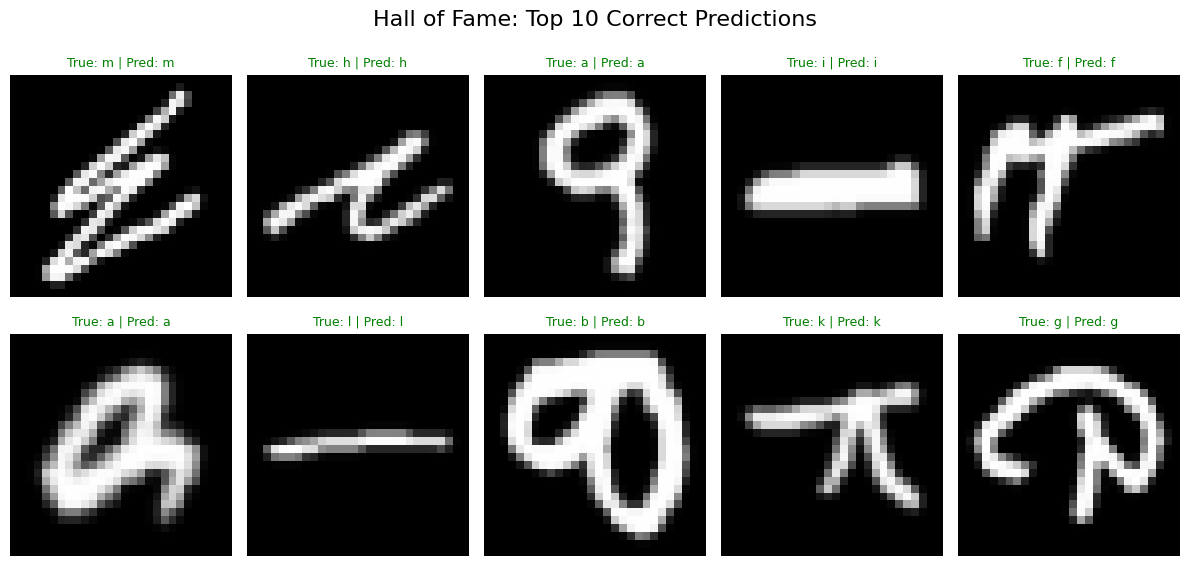


===== COPY THIS FOR DOCUMENT =====
Best units          : 512
Best learning rate  : 0.001
Test Loss           : 0.4339
Test Accuracy       : 88.41%


In [2]:
import tensorflow as tf
from tensorflow import keras
import keras_tuner as kt
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.metrics import confusion_matrix

print(f"TensorFlow Version: {tf.__version__}")

# ── 1. Load EMNIST Letters ──────────────────────────────────────────────────
# emnist is not built into keras, so we use tensorflow_datasets
import tensorflow_datasets as tfds

ds_train_full, ds_test = tfds.load(
    'emnist/letters',
    split=['train', 'test'],
    as_supervised=True
)

def preprocess(image, label):
    image = tf.cast(image, tf.float32) / 255.0
    image = tf.squeeze(image, axis=-1)          # (28,28,1) → (28,28)
    label = label - 1                           # EMNIST letters are 1-indexed (1-26) → 0-25
    return image, label

ds_train_full = ds_train_full.map(preprocess)
ds_test       = ds_test.map(preprocess)

# Convert to numpy for Keras
x_train = np.array([x.numpy() for x, _ in ds_train_full])
y_train = np.array([y.numpy() for _, y in ds_train_full])
x_test  = np.array([x.numpy() for x, _ in ds_test])
y_test  = np.array([y.numpy() for _, y in ds_test])

print(f"Train shape: {x_train.shape}, Test shape: {x_test.shape}")
print(f"Classes: {len(np.unique(y_train))} letters (a–z)")

# ── 2. Model Builder for Keras Tuner ───────────────────────────────────────
def model_builder(hp):
    model = keras.Sequential()
    model.add(keras.layers.Flatten(input_shape=(28, 28)))
    hp_units = hp.Int('units', min_value=32, max_value=512, step=32)
    model.add(keras.layers.Dense(units=hp_units, activation='relu'))
    model.add(keras.layers.Dense(26, activation='softmax'))   # 26 letter classes
    hp_lr = hp.Choice('learning_rate', values=[1e-2, 1e-3, 1e-4])
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=hp_lr),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

# ── 3. Hyperband Tuner ─────────────────────────────────────────────────────
tuner = kt.Hyperband(
    model_builder,
    objective='val_accuracy',
    max_epochs=10,
    factor=3,
    directory='my_dir_emnist',
    project_name='emnist_letters_tuning'
)

stop_early = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5)

tuner.search(x_train, y_train, epochs=10, validation_split=0.2, callbacks=[stop_early])

best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]
print(f"""
Hyperparameter search complete.
Optimal units in hidden layer : {best_hps.get('units')}
Optimal learning rate         : {best_hps.get('learning_rate')}
""")

# ── 4. Train Best Model ────────────────────────────────────────────────────
model = tuner.hypermodel.build(best_hps)
history = model.fit(x_train, y_train, epochs=10, validation_split=0.2)

# ── 5. Evaluate ────────────────────────────────────────────────────────────
eval_result = model.evaluate(x_test, y_test)
print(f"[Test Loss, Test Accuracy]: {eval_result}")

# ── 6. Accuracy Plot ───────────────────────────────────────────────────────
plt.figure()
plt.plot(history.history['accuracy'],     label='accuracy')
plt.plot(history.history['val_accuracy'], label='val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.ylim([0.5, 1])
plt.legend(loc='lower right')
plt.title('Training vs Validation Accuracy')
plt.savefig('accuracy_plot.png', dpi=150, bbox_inches='tight')
plt.show()

# ── 7. Confusion Matrix ────────────────────────────────────────────────────
y_pred_probs   = model.predict(x_test)
y_pred_classes = np.argmax(y_pred_probs, axis=1)

conf_matrix = confusion_matrix(y_test, y_pred_classes)
plt.figure(figsize=(14, 12))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=list('abcdefghijklmnopqrstuvwxyz'),
            yticklabels=list('abcdefghijklmnopqrstuvwxyz'))
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix (Heatmap)')
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

# ── 8. Top 10 Misclassified ────────────────────────────────────────────────
errors = (y_pred_classes != y_test)
x_err  = x_test[errors]
y_err  = y_test[errors]
p_err  = y_pred_classes[errors]
letters = list('abcdefghijklmnopqrstuvwxyz')

plt.figure(figsize=(12, 6))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_err[i], cmap='gray')
    plt.title(f"True: {letters[y_err[i]]}\nPred: {letters[p_err[i]]}", color='red', fontsize=9)
    plt.axis('off')
plt.suptitle("Top 10 Misclassified Images", fontsize=16)
plt.tight_layout()
plt.savefig('misclassified.png', dpi=150, bbox_inches='tight')
plt.show()

# ── 9. Random Sample Prediction ───────────────────────────────────────────
index        = np.random.randint(0, len(x_test))
sample_image = x_test[index]
true_label   = y_test[index]
prediction   = model.predict(sample_image.reshape(1, 28, 28))
pred_label   = np.argmax(prediction)

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.imshow(sample_image, cmap='gray')
plt.title(f"True: {letters[true_label]} | Predicted: {letters[pred_label]}")
plt.axis('off')
plt.subplot(1, 2, 2)
plt.bar(range(26), prediction[0])
plt.xticks(range(26), list('abcdefghijklmnopqrstuvwxyz'), fontsize=7)
plt.xlabel("Letter Class")
plt.ylabel("Probability")
plt.title("Model Confidence")
plt.savefig('sample_prediction.png', dpi=150, bbox_inches='tight')
plt.show()

# ── 10. Hall of Fame (Top 10 Correct) ────────────────────────────────────
correct_indices = np.where(y_pred_classes == y_test)[0]
plt.figure(figsize=(12, 6))
for i in range(10):
    idx = correct_indices[i]
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_test[idx], cmap='gray')
    plt.title(f"True: {letters[y_test[idx]]} | Pred: {letters[y_pred_classes[idx]]}",
              color='green', fontsize=9)
    plt.axis('off')
plt.suptitle("Hall of Fame: Top 10 Correct Predictions", fontsize=16)
plt.tight_layout()
plt.savefig('correct_predictions.png', dpi=150, bbox_inches='tight')
plt.show()

# ── 11. Print summary for document ────────────────────────────────────────
print("\n===== COPY THIS FOR DOCUMENT =====")
print(f"Best units          : {best_hps.get('units')}")
print(f"Best learning rate  : {best_hps.get('learning_rate')}")
print(f"Test Loss           : {eval_result[0]:.4f}")
print(f"Test Accuracy       : {eval_result[1]*100:.2f}%")
print("==================================")